En este notebook se procesan los datos obtenidos, punto a punto mediante la plataforma https://automeris.io/wpd/, a partir de la gràfica del siguiente estudio: https://www.researchgate.net/publication/360350397_Elastic_storage_enables_robustness_of_flapping_wing_dynamics
Los datos en realidad son de un moscardòn (bumblebee) pero estos animales son muy cercano a las abejas.

C:\Users\Santamaria\AppData\Local\Temp\ipykernel_29492\2415545980.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nuevo_dataframe["time/T_position"] = df_position_elevation[0:222][df_position_elevation["Type"] == "position"]["time/T"].reset_index(drop=True)
C:\Users\Santamaria\AppData\Local\Temp\ipykernel_29492\2415545980.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nuevo_dataframe["positional_angle"] = df_position_elevation[0:222][df_position_elevation["Type"] == "position"]["Angle(°)"].reset_index(drop=True)


     time/T_position  positional_angle  time/T_elevation  elevation_angle  \
492              NaN               NaN               NaN              NaN   
493              NaN               NaN               NaN              NaN   
494              NaN               NaN               NaN              NaN   
495              NaN               NaN               NaN              NaN   
496              NaN               NaN               NaN              NaN   
497              NaN               NaN               NaN              NaN   

     time/T_feathering  feathering_angle  
492                NaN               NaN  
493                NaN               NaN  
494                NaN               NaN  
495                NaN               NaN  
496                NaN               NaN  
497                NaN               NaN  


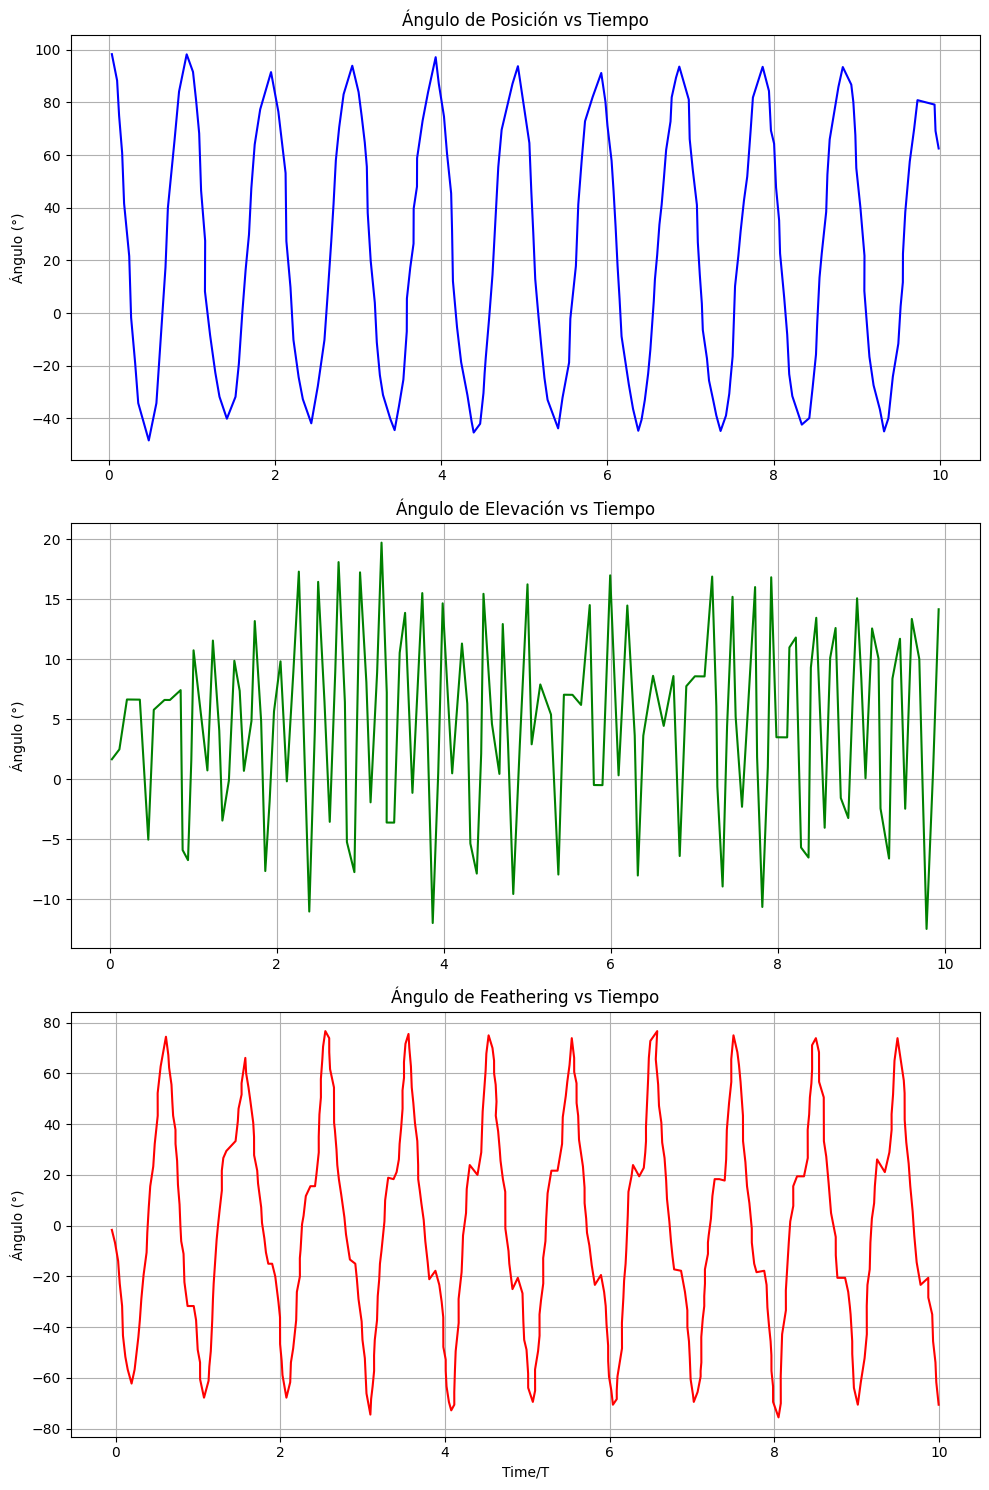

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_feathering = pd.read_csv('feathering.csv')
df_position_elevation = pd.read_csv('position_elevation.csv')

nuevo_dataframe = pd.DataFrame(index=range(max(len(df_position_elevation), len(df_feathering))))

nuevo_dataframe["time/T_position"] = df_position_elevation[0:222][df_position_elevation["Type"] == "position"]["time/T"].reset_index(drop=True)
nuevo_dataframe["positional_angle"] = df_position_elevation[0:222][df_position_elevation["Type"] == "position"]["Angle(°)"].reset_index(drop=True)

nuevo_dataframe["time/T_elevation"] = df_position_elevation[df_position_elevation["Type"] == "elevation"]["time/T"].reset_index(drop=True)
nuevo_dataframe["elevation_angle"] = df_position_elevation[df_position_elevation["Type"] == "elevation"]["Angle(°)"].reset_index(drop=True)

nuevo_dataframe["time/T_feathering"] = df_feathering["time/T"].reset_index(drop=True)
nuevo_dataframe["feathering_angle"] = df_feathering["Angle(°)"].reset_index(drop=True)

print(nuevo_dataframe.tail(6))


# Crear una figura con 3 subgráficas (3 filas, 1 columna)
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=False)

# 1. Gráfica de Posición
axs[0].plot(nuevo_dataframe["time/T_position"], nuevo_dataframe["positional_angle"], color='blue', label='Position')
axs[0].set_title("Ángulo de Posición vs Tiempo")
axs[0].set_ylabel("Ángulo (°)")
axs[0].grid(True)

# 2. Gráfica de Elevación
axs[1].plot(nuevo_dataframe["time/T_elevation"], nuevo_dataframe["elevation_angle"], color='green', label='Elevation')
axs[1].set_title("Ángulo de Elevación vs Tiempo")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)

# 3. Gráfica de Feathering
axs[2].plot(nuevo_dataframe["time/T_feathering"], nuevo_dataframe["feathering_angle"], color='red', label='Feathering')
axs[2].set_title("Ángulo de Feathering vs Tiempo")
axs[2].set_xlabel("Time/T")
axs[2].set_ylabel("Ángulo (°)")
axs[2].grid(True)

# Ajustar el espacio entre gráficas para que no se amontonen los títulos
plt.tight_layout()
plt.show()

nuevo_dataframe.to_csv("angulos.csv", index=False)


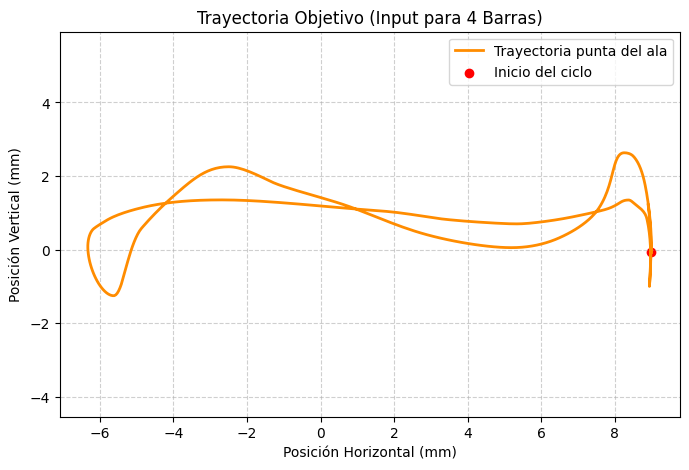

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

df_angulos = pd.read_csv("angulos.csv")

# ==========================================
# 1. PARÁMETROS FÍSICOS Y DE DATOS
# ==========================================
f = 200 
T = 1 / f
L_ala = 9.0


# --- REVISIÓN DE LIMPIEZA Y FILTRADO DE CICLO ---

# 1. POSICIÓN: Ordenar -> Borrar Duplicados de Tiempo -> Borrar NaNs
df_pos_temp = (df_angulos[["time/T_position", "positional_angle"]]
               .sort_values("time/T_position")
               .drop_duplicates(subset=["time/T_position"])
               .dropna())

# *** FILTRADO DE CICLO: Solo primer ciclo ***
# Filtramos para quedarnos con datos donde time/T es <= 7.0
df_pos_clean = df_pos_temp[df_pos_temp["time/T_position"].between(0, 10)]

# Convertimos los datos filtrados a numpy array para procesar
t_orig_pos = df_pos_clean["time/T_position"].values * T # Tiempo real (segundos)
phi_orig = np.radians(df_pos_clean["positional_angle"].values)


# 2. ELEVACIÓN: Mismo proceso
df_elev_temp = (df_angulos[["time/T_elevation", "elevation_angle"]]
                .sort_values("time/T_elevation")
                .drop_duplicates(subset=["time/T_elevation"])
                .dropna())

# *** FILTRADO DE CICLO: Solo primer ciclo ***
df_elev_clean = df_elev_temp[df_elev_temp["time/T_elevation"].between(5.8, 7)]

t_orig_elev = df_elev_clean["time/T_elevation"].values * T # Tiempo real (segundos)
theta_orig = np.radians(df_elev_clean["elevation_angle"].values)


# -- Re-definir t_suave usando los límites del CICLO AISLADO --
# Es vital recalcular esto. Usamos el max de los min y min de los max
# del ciclo 1 para asegurar que Pchip interpolará dentro de un rango válido.
t_min = max(t_orig_pos.min(), t_orig_elev.min())
t_max = min(t_orig_pos.max(), t_orig_elev.max())

# Creamos 500 puntos distribuidos uniformemente para este único ciclo
t_suave = np.linspace(t_min, t_max, 500)


# -- Continuar con la interpolación y cálculo de x, y (igual que antes) --
interp_phi = PchipInterpolator(t_orig_pos, phi_orig)
interp_theta = PchipInterpolator(t_orig_elev, theta_orig)

phi_suave = interp_phi(t_suave)
theta_suave = interp_theta(t_suave)

x_punta = L_ala * np.cos(theta_suave) * np.sin(phi_suave)
y_punta = L_ala * np.sin(theta_suave)


# ==========================================
# 3. CÁLCULO DE LA TRAYECTORIA (X, Y)
# ==========================================
# Proyección 2D para el modelo de 4 barras
x_punta = L_ala * np.cos(theta_suave) * np.sin(phi_suave)
y_punta = L_ala * np.sin(theta_suave)

# ==========================================
# 4. GRÁFICA PARA TU COMPAÑERO
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(x_punta, y_punta, color='darkorange', lw=2, label='Trayectoria punta del ala')
plt.scatter(x_punta[0], y_punta[0], color='red', label='Inicio del ciclo')

plt.title("Trayectoria Objetivo (Input para 4 Barras)")
plt.xlabel("Posición Horizontal (mm)")
plt.ylabel("Posición Vertical (mm)")
plt.axis('equal') # Importante para no deformar la elipse
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Exportar para el código del 4 barras
df_objetivo = pd.DataFrame({'x': x_punta, 'y': y_punta})
df_objetivo.to_csv("trayectoria_abeja.csv", index=False)


En el siguiente código se limita la cantidad de datos a 20

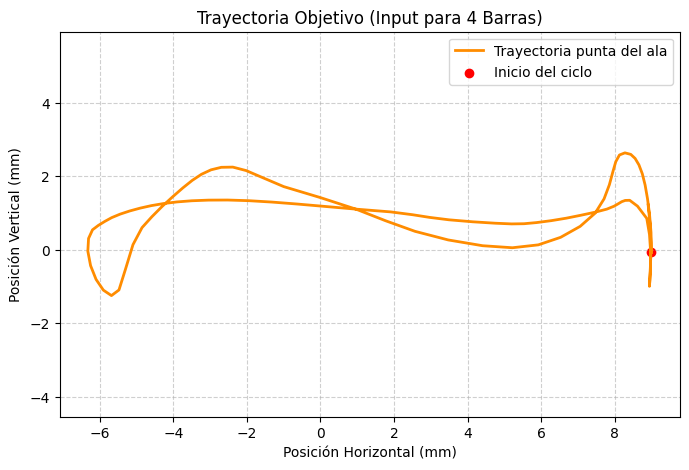

In [8]:
# 1. Definimos los 100 puntos (o el número que prefieras)
num_puntos = 100
t_suave = np.linspace(t_min, t_max, num_puntos) # <--- Aquí ocurre la magia

# 2. Re-calculamos las trayectorias con esos 100 puntos
phi_suave = interp_phi(t_suave)
theta_suave = interp_theta(t_suave)

# 3. Calculamos las coordenadas (x, y) para estos 100 puntos
x_punta_resumido = L_ala * np.cos(theta_suave) * np.sin(phi_suave)
y_punta_resumido = L_ala * np.sin(theta_suave)

# 4. Ahora ya tienes tus 100 puntos en 'x_punta_resumido' e 'y_punta_resumido'
# Puedes imprimirlos o guardarlos en un CSV para tu compañero
df_resumido = pd.DataFrame({'x': x_punta_resumido, 'y': y_punta_resumido})
df_resumido.to_csv("trayectoria_abeja_100_datos.csv", index=False)
plt.figure(figsize=(8, 5))
plt.plot(x_punta_resumido, y_punta_resumido, color='darkorange', lw=2, label='Trayectoria punta del ala')
plt.scatter(x_punta_resumido[0], y_punta_resumido[0], color='red', label='Inicio del ciclo')

plt.title("Trayectoria Objetivo (Input para 4 Barras)")
plt.xlabel("Posición Horizontal (mm)")
plt.ylabel("Posición Vertical (mm)")
plt.axis('equal') # Importante para no deformar la elipse
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()
